# Result 05 — Where biodiversity-loss evidence is present—and absent

**Status:** supporting geographic coverage audit; not a fifth manuscript finding.

**Question:** across every place in the IPBES mapping, where is country-resolved
biodiversity-loss research concentrated, and which mapped places have little, no, or
structurally unresolvable evidence?

The visual is a simplified **centre → region → country** wheel; subregion remains available
in the exported analytical tables but is omitted from the figure. Every displayed place gets
one equal angular slot. Read clockwise from the 12 o'clock seam: regions descend by their
publication-fractional attention, and countries descend within each region. Outward radial
length shows fractional attention on a labelled log scale. Positive country shares below
0.1% use a pale version of their region hue. Countries with zero captured evidence are not
drawn; mapping entries without an ISO3 join key are also omitted from the figure.

This notebook uses the exact **146,631-publication, 213-country** historical-income-eligible
base from Result 02. All 257 IPBES mapping leaves remain in the exports; the wheel displays
only the 213 countries with captured evidence and a valid ISO3 join key.

In [1]:
import hashlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "data_helpers").is_dir() and (candidate / "checklists").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the biodiversity repository root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from data_helpers import results_config, visualization
from data_helpers.analysis.geo.attention import prepare_geography_attention
from data_helpers.analysis.geo.attention_plotting import (
    plot_geographic_attention_radial,
)
from data_helpers.analysis.geo.geography import CROSSWALK_PATH
from data_helpers.prep import evidence_corpus_prep

In [4]:
visualization.apply_style()

RESULTS_CONFIG = results_config.load_results_config()
ATTENTION_CONFIG = RESULTS_CONFIG["geography_attention"]
EVIDENCE_CONFIG = RESULTS_CONFIG["biodiversity_evidence_prep"]
DRIVER_CONFIG = RESULTS_CONFIG["driver_composition"]
INCOME_CONFIG = RESULTS_CONFIG["world_bank_income"]
INCOME_GROUPS = INCOME_CONFIG["group_order"]

OUTPUT_DIR = PROJECT_ROOT / ATTENTION_CONFIG["output_directory"]
DATA_DIR = OUTPUT_DIR / ATTENTION_CONFIG["data_subdirectory"]
TABLE_DIR = OUTPUT_DIR / ATTENTION_CONFIG["table_subdirectory"]
FIGURE_DIR = OUTPUT_DIR / ATTENTION_CONFIG["figure_subdirectory"]
for directory in (DATA_DIR, TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CORPUS_DIR = PROJECT_ROOT / EVIDENCE_CONFIG["output_directory"]
RESULT02_ASSIGNMENTS_PATH = (
    PROJECT_ROOT
    / DRIVER_CONFIG["output_directory"]
    / DRIVER_CONFIG["data_subdirectory"]
    / DRIVER_CONFIG["classified_assignments_file"]
)

print("Inputs")
for label, path in (
    ("integrated evidence corpus", CORPUS_DIR),
    ("Result 02 classified base", RESULT02_ASSIGNMENTS_PATH),
    ("IPBES hierarchy mapping   ", CROSSWALK_PATH),
):
    status = "found" if path.exists() else "MISSING"
    print(f"  {label}: {path.relative_to(PROJECT_ROOT)}  [{status}]")

missing = [
    path
    for path in (CORPUS_DIR, RESULT02_ASSIGNMENTS_PATH, CROSSWALK_PATH)
    if not path.exists()
]
if missing:
    raise FileNotFoundError(
        "Run the evidence-corpus preparation and Result 02 first; missing: "
        f"{[str(path.relative_to(PROJECT_ROOT)) for path in missing]}"
    )
print(f"\nOutput section: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")

Inputs
  integrated evidence corpus: notebooks/data_processing/outputs/04_biodiversity_evidence_corpus_prep  [found]
  Result 02 classified base: notebooks/results/outputs/02_income_composition/data/historical_income_publication_country_assignments.parquet  [found]
  IPBES hierarchy mapping   : checklists/mappings/ipbes_regions.json  [found]

Output section: notebooks/results/outputs/05_geography_attention


## 1. Build the complete hierarchy at publication × country grain

Start from the exact publication identifiers retained by Result 02 after country complete-case,
World Bank linkage, historical-income classification, and 2000–2025 filtering. Parse the
multi-valued country field against the canonical IPBES mapping, then de-duplicate each retained
publication × country pair. A publication naming (k) resolved
countries contributes (1/k) to each, so its total attention weight remains one.

Direct region and subregion predictions are not mixed into this hierarchy: each parent
is derived from its resolved country leaf, guaranteeing exact nesting. The Result 02 base
already contains only income-classified, country-resolved complete cases.

In [5]:
assert ATTENTION_CONFIG["primary_start_year"] == DRIVER_CONFIG["primary_start_year"]
assert ATTENTION_CONFIG["primary_end_year"] == DRIVER_CONFIG["primary_end_year"]

result02_assignments = pd.read_parquet(
    RESULT02_ASSIGNMENTS_PATH,
    columns=["UT", "publication_year", "historical_income_group"],
)
shared_base_ids = (
    result02_assignments.loc[
        result02_assignments["publication_year"].between(
            DRIVER_CONFIG["primary_start_year"],
            DRIVER_CONFIG["primary_end_year"],
        )
        & result02_assignments["historical_income_group"].isin(INCOME_GROUPS),
        "UT",
    ]
    .drop_duplicates()
)
assert len(shared_base_ids) == 146_631
shared_base_id_set = set(shared_base_ids)

corpus_all = evidence_corpus_prep.BiodiversityEvidenceStore(CORPUS_DIR).load(
    columns=["UT", "publication_year", "s2_dir", "pred_countries"]
).publications
missing_base_ids = shared_base_id_set.difference(corpus_all["UT"])
assert not missing_base_ids, f"Result 02 base IDs missing from corpus: {len(missing_base_ids):,}"
corpus_df = corpus_all.loc[corpus_all["UT"].isin(shared_base_id_set)].copy()
assert corpus_df["UT"].nunique() == len(shared_base_ids)

geography = prepare_geography_attention(
    corpus_df,
    start_year=ATTENTION_CONFIG["primary_start_year"],
    end_year=ATTENTION_CONFIG["primary_end_year"],
    direction=ATTENTION_CONFIG["direction"],
    low_evidence_threshold=ATTENTION_CONFIG["low_evidence_threshold"],
)
audit_values = geography.audit.set_index("metric")["value"]

print(
    f"Prepared {int(audit_values['mapped_publication_country_assignments']):,} unique "
    "publication × country assignments across "
    f"{int(audit_values['mapping_leaves']):,} IPBES mapping leaves."
)

Prepared 165,216 unique publication × country assignments across 257 IPBES mapping leaves.


## 2. Verify the shared country-resolved base

The centre denominator is the Result 02 income-classifiable publication base, not the complete
biodiversity-loss corpus. Result 02 has already removed unresolved or income-ineligible records.
The coverage tables below verify that every inherited publication enters the hierarchy.

In [6]:
coverage_display = geography.coverage.copy()
coverage_display["share_pct"] = coverage_display["share_pct"].round(2)
display(coverage_display.style.format({
    "publication_count": "{:,}",
    "total_publications": "{:,}",
    "share_pct": "{:.2f}%",
}).hide(axis="index"))

print("Mutually exclusive reasons among publications without a mapped country")
display(
    geography.coverage_reasons.style.format({
        "publication_count": "{:,}",
        "share_of_no_mapped_pct": "{:.2f}%",
        "share_of_analysis_pct": "{:.2f}%",
    }).hide(axis="index")
)

display(
    geography.audit.style.format({"value": lambda value: f"{value:,.6g}"})
    .hide(axis="index")
)

coverage_status,publication_count,total_publications,share_pct
mapped_country,"146,631","146,631",100.00%
no_mapped_country,0,"146,631",0.00%


Mutually exclusive reasons among publications without a mapped country


coverage_reason,publication_count,share_of_no_mapped_pct,share_of_analysis_pct


metric,value
input_publications,"146,631"
direction_matching_publications,"146,631"
window_publications_before_country_validation,"146,631"
complete_case_excluded_publications,0
analysis_publications,"146,631"
mapped_country_publications,"146,631"
no_mapped_country_publications,0
mapped_country_coverage_pct,100
empty_country_list_publications,0
mentions_mapped,"165,217"


## 3. Anti-analysis: low, zero, and unresolvable places

`whole_publications` is the number of distinct publications naming a place and defines
the requested `<100` threshold. These counts overlap across countries and therefore are
not summed to measure global attention. Zero-captured leaves and mapping entries without
an ISO3 key are kept as different states: the latter cannot be tested against the
publication country codes at all.

In [7]:
threshold = ATTENTION_CONFIG["low_evidence_threshold"]
country_table = geography.countries.copy()
display_region_order = (
    geography.hierarchy.loc[
        geography.hierarchy["node_type"].eq("region"),
        ["label", "attention_share_pct"],
    ]
    .sort_values(["attention_share_pct", "label"], ascending=[False, True])
    ["label"]
    .tolist()
)
country_table["evidence_band"] = np.select(
    [
        country_table["key_status"].eq("unresolvable_key"),
        country_table["evidence_status"].eq("zero_captured"),
        country_table["whole_publications"].lt(threshold).fillna(False),
    ],
    ["Unresolvable mapping key", "No captured evidence in shared base", "1–99 publications"],
    default="≥100 publications",
)
band_order = [
    "≥100 publications",
    "1–99 publications",
    "No captured evidence in shared base",
    "Unresolvable mapping key",
]

status_by_region = (
    country_table.groupby(["region", "evidence_band"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=display_region_order, columns=band_order, fill_value=0)
)
status_by_region.loc["All IPBES leaves"] = status_by_region.sum(axis=0)
display(status_by_region.style.format("{:,}"))

observed_low = country_table.loc[
    country_table["evidence_band"].eq("1–99 publications"),
    ["region", "subregion", "country", "iso3", "whole_publications"],
].sort_values(["whole_publications", "region", "subregion", "country"])
zero_captured = country_table.loc[
    country_table["evidence_band"].eq("No captured evidence in shared base"),
    ["region", "subregion", "country", "iso3", "whole_publications"],
].sort_values(["region", "subregion", "country"])
unresolvable_leaves = country_table.loc[
    country_table["evidence_band"].eq("Unresolvable mapping key"),
    ["region", "subregion", "country", "iso3", "key_status"],
].sort_values(["region", "subregion", "country"])
gap_inventory = country_table.loc[
    ~country_table["evidence_band"].eq("≥100 publications"),
    [
        "region",
        "subregion",
        "country",
        "iso3",
        "key_status",
        "whole_publications",
        "evidence_band",
    ],
].sort_values(["evidence_band", "whole_publications", "region", "country"], na_position="last")

print(f"Observed but below {threshold}: {len(observed_low):,} places")
with pd.option_context("display.max_rows", None):
    display(
        observed_low.style.format(
            {"whole_publications": "{:,}"}, na_rep="—"
        ).hide(axis="index")
    )

print(f"Valid ISO3 but zero captured evidence in shared base: {len(zero_captured):,} places")
display(
    zero_captured.style.format(
        {"whole_publications": "{:,}"}, na_rep="—"
    ).hide(axis="index")
)

print(f"No resolvable ISO3 key in the IPBES mapping: {len(unresolvable_leaves):,} places")
display(unresolvable_leaves.style.hide(axis="index"))

evidence_band,≥100 publications,1–99 publications,No captured evidence in shared base,Unresolvable mapping key
region,,,,
Asia and the Pacific,35,23,13,4
Americas,22,23,12,1
Europe and Central Asia,42,14,6,3
Africa,26,28,4,0
Antarctica,0,0,1,0
All IPBES leaves,125,88,36,8


Observed but below 100: 88 places


region,subregion,country,iso3,whole_publications
Americas,Caribbean,Sint Maarten (Dutch part),SXM,1
Asia and the Pacific,Oceania,Nauru,NRU,2
Americas,Caribbean,Aruba,ABW,4
Europe and Central Asia,Central and Western Europe,Isle of Man,IMN,4
Europe and Central Asia,Central and Western Europe,Monaco,MCO,4
Americas,Caribbean,Saint Vincent and the Grenadines,VCT,5
Europe and Central Asia,Central and Western Europe,Andorra,AND,6
Americas,Caribbean,Saint Kitts and Nevis,KNA,7
Americas,Caribbean,Virgin Islands (British),VGB,8
Europe and Central Asia,Central and Western Europe,Gibraltar,GIB,8


Valid ISO3 but zero captured evidence in shared base: 36 places


region,subregion,country,iso3,whole_publications
Africa,East Africa and adjacent islands,Mayotte,MYT,0
Africa,East Africa and adjacent islands,Réunion,REU,0
Africa,North Africa,Western Sahara*,ESH,0
Africa,Southern Africa,"Saint Helena, Ascension and Tristan da Cunha",SHN,0
Americas,Caribbean,Anguilla,AIA,0
Americas,Caribbean,"Bonaire, Sint Eustatius and Saba",BES,0
Americas,Caribbean,Guadeloupe,GLP,0
Americas,Caribbean,Martinique,MTQ,0
Americas,Caribbean,Montserrat,MSR,0
Americas,Caribbean,Saint Barthélemy,BLM,0


No resolvable ISO3 key in the IPBES mapping: 8 places


region,subregion,country,iso3,key_status
Americas,Caribbean,United States Minor Outlying Islands (Navassa),,unresolvable_key
Asia and the Pacific,Oceania,Clipperton Island,,unresolvable_key
Asia and the Pacific,Oceania,Hawaii (USA),,unresolvable_key
Asia and the Pacific,South-East Asia,Paracel Islands,,unresolvable_key
Asia and the Pacific,South-East Asia,Spratly Islands,,unresolvable_key
Europe and Central Asia,Central and Western Europe,Akrotiri and Dhekelia,,unresolvable_key
Europe and Central Asia,Central and Western Europe,Kosovo,,unresolvable_key
Europe and Central Asia,Central and Western Europe,Northern Cyprus,,unresolvable_key


Unresolved source tokens were handled upstream by Result 02's complete-case rule. The shared
base should therefore introduce no additional exclusions here. This remains distinct from the
IPBES mapping's eight no-key leaves, which cannot be assigned evidence counts.

In [8]:
display(
    geography.unresolved_tokens.head(30).style.format({
        "mention_count": "{:,}",
        "publication_count": "{:,}",
    }).hide(axis="index")
)
print(
    f"Additional exclusions after inheriting the Result 02 base: "
    f"{int(audit_values['complete_case_excluded_publications']):,}."
)

token,mention_count,publication_count


Additional exclusions after inheriting the Result 02 base: 0.


## 4. Research attention: an additive composition

For the radial bars and parent shares, each country-resolved publication contributes one
publication-equivalent in total. `attention_share_pct` therefore sums exactly to 100%
over countries and rolls up additively to IPBES subregions and regions. Whole-publication
counts remain alongside it because they are easier to interpret locally and define the
evidence-support bands.

In [9]:
region_attention = geography.hierarchy.loc[
    geography.hierarchy["node_type"].eq("region"),
    [
        "label",
        "child_count",
        "whole_publications",
        "fractional_publication_equivalent",
        "attention_share_pct",
    ],
].rename(columns={"label": "region", "child_count": "subregions"})
region_attention = region_attention.sort_values(
    ["attention_share_pct", "region"], ascending=[False, True]
).reset_index(drop=True)
region_attention["mapping_leaves"] = region_attention["region"].map(
    geography.countries.groupby("region", observed=True).size()
)
region_attention = region_attention[
    [
        "region",
        "subregions",
        "mapping_leaves",
        "whole_publications",
        "fractional_publication_equivalent",
        "attention_share_pct",
    ]
]
display(
    region_attention.style.format({
        "subregions": "{:,}",
        "mapping_leaves": "{:,}",
        "whole_publications": "{:,}",
        "fractional_publication_equivalent": "{:,.1f}",
        "attention_share_pct": "{:.2f}%",
    }).hide(axis="index")
)

ranked_countries = geography.countries.loc[
    geography.countries["key_status"].eq("valid_iso3")
].sort_values("attention_share_pct", ascending=False).copy()
ranked_countries["cumulative_attention_pct"] = ranked_countries[
    "attention_share_pct"
].cumsum()
display(
    ranked_countries.head(20)[
        [
            "country",
            "iso3",
            "region",
            "whole_publications",
            "fractional_publication_equivalent",
            "attention_share_pct",
            "cumulative_attention_pct",
        ]
    ].style.format({
        "whole_publications": "{:,}",
        "fractional_publication_equivalent": "{:,.1f}",
        "attention_share_pct": "{:.2f}%",
        "cumulative_attention_pct": "{:.2f}%",
    }).hide(axis="index")
)
print(
    "Cumulative fractional attention — "
    f"top 10: {ranked_countries.head(10)['attention_share_pct'].sum():.1f}%; "
    f"top 25: {ranked_countries.head(25)['attention_share_pct'].sum():.1f}%."
)

region,subregions,mapping_leaves,whole_publications,fractional_publication_equivalent,attention_share_pct
Asia and the Pacific,5,75,"50,977","50,356.8",34.34%
Americas,4,58,"50,350","49,792.1",33.96%
Europe and Central Asia,3,65,"33,849","33,235.1",22.67%
Africa,5,58,"13,564","13,246.9",9.03%
Antarctica,1,1,0,0.0,0.00%


country,iso3,region,whole_publications,fractional_publication_equivalent,attention_share_pct,cumulative_attention_pct
United States of America (the),USA,Americas,"25,667","24,349.7",16.61%,16.61%
China,CHN,Asia and the Pacific,"20,593","20,090.2",13.70%,30.31%
Brazil,BRA,Americas,"8,631","8,245.9",5.62%,35.93%
Australia,AUS,Asia and the Pacific,"6,632","6,398.3",4.36%,40.29%
India,IND,Asia and the Pacific,"6,668","6,353.0",4.33%,44.63%
Canada,CAN,Americas,"6,794","5,944.7",4.05%,48.68%
Spain,ESP,Europe and Central Asia,"4,517","3,964.9",2.70%,51.39%
Italy,ITA,Europe and Central Asia,"3,837","3,424.0",2.34%,53.72%
Mexico,MEX,Americas,"3,457","3,115.7",2.12%,55.85%
United Kingdom of Great Britain and Northern Ireland (the),GBR,Europe and Central Asia,"2,882","2,548.6",1.74%,57.58%


Cumulative fractional attention — top 10: 57.6%; top 25: 75.4%.


## 5. Clockwise region → place attention wheel

The visual rings encode only IPBES region and one equal-angle slot per mapping leaf.
Subregion remains in `hierarchy_attention.csv` but is omitted here because a global
attention ranking within each region does not preserve contiguous subregion blocks.

Read clockwise from the 12 o'clock seam. Regions descend by additive fractional
attention; within each region, positive-attention places descend by the same measure.
Zero-captured and no-key leaves are omitted from the figure. Outward
bar length is log-scaled fractional attention, with labelled guide rings in percentage
points. The transform preserves variation among small shares, but wedge area is not a
quantitative measure.

In [10]:
# The former callout-based presentation figure was retired; the single
# publication figure below is the authoritative visual output.

### Publication figure

The publication figure labels every displayed place by a concise name on one line, grouped by
region and descending in attention within each region. Parenthetical qualifiers and trailing source asterisks are omitted only
for rendering; concise display overrides keep every label to 20 characters and four words or
fewer. Country labels above 1% fractional attention are bold, while labels below 0.1% are
italic. Shared-base zero and no-key
entries are omitted from the wheel;
original names, exact codes, counts, statuses, shares, and subregions remain available in
`country_attention.csv`.

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/05_geography_attention/figures/geography_attention_hierarchy_reference.pdf


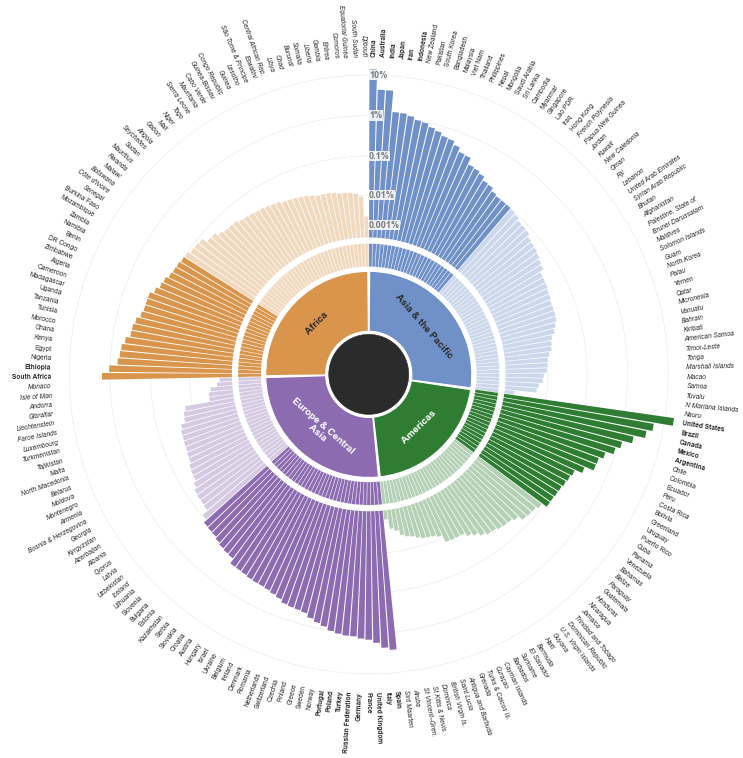

In [11]:
publication_leaves = geography.countries.loc[
    geography.countries["evidence_status"].eq("observed")
    & geography.countries["key_status"].eq("valid_iso3")
].copy()
assert len(publication_leaves) == 213
assert publication_leaves["attention_share_pct"].gt(0).all()

publication_figure = plot_geographic_attention_radial(
    publication_leaves,
    count_col="whole_publications",
    region_order=display_region_order,
    start_angle=ATTENTION_CONFIG["clockwise_start_angle"],
    show_subregions=False,
    sort_by_attention=True,
    region_colors=ATTENTION_CONFIG["region_colors"],
    low_attention_threshold_pct=ATTENTION_CONFIG["low_attention_threshold_pct"],
    highlight_attention_threshold_pct=ATTENTION_CONFIG["highlight_attention_threshold_pct"],
    attention_ticks_pct=[0.001, 0.01, 0.1, 1, 10],
    figsize=(7.5, 7.5),
)
visualization.save_figure(
    publication_figure,
    FIGURE_DIR / ATTENTION_CONFIG["reference_figure_filename"],
    formats=["pdf"],
    dpi=300,
    pad_inches=0.08,
)
plt.show()

## 6. Reconciliation and export

The pinned checks below make changes in the evidence corpus, mapping universe, or parsing
rules fail visibly. The exported gap inventory is the complete answer to the anti-analysis.
In the full leaf table, `below_evidence_threshold` applies only to valid ISO3 leaves;
no-key leaves keep nullable evidence values rather than being misrepresented as zero.

In [12]:
expected_audit = {
    "window_publications_before_country_validation": 146_631,
    "complete_case_excluded_publications": 0,
    "analysis_publications": 146_631,
    "mapped_country_publications": 146_631,
    "no_mapped_country_publications": 0,
    "mapped_publication_country_assignments": 165_216,
    "mapping_leaves": 257,
    "mapping_valid_iso3_leaves": 249,
    "mapping_unresolvable_key_leaves": 8,
    "observed_country_leaves": 213,
    "supported_country_leaves": 125,
    "observed_below_threshold_country_leaves": 88,
    "zero_captured_country_leaves": 36,
    "below_threshold_valid_iso3_leaves": 124,
    "excluded_publications_with_mapped_country_before_exclusion": 0,
}
for metric, expected in expected_audit.items():
    actual = int(audit_values[metric])
    assert actual == expected, f"{metric}: expected {expected:,}, found {actual:,}"

assert len(geography.hierarchy) == 281  # root + 5 regions + 18 subregions + 257 leaves
assert geography.countries["node_id"].is_unique
assert not geography.assignments.duplicated(["UT", "iso3"]).any()
assert np.allclose(
    geography.assignments.groupby("UT")["fractional_weight"].sum().to_numpy(),
    1.0,
)
assert np.isclose(geography.countries["attention_share_pct"].sum(), 100.0)
assert np.isclose(region_attention["attention_share_pct"].sum(), 100.0)
assert len(observed_low) == 88
assert len(zero_captured) == 36
assert len(unresolvable_leaves) == 8
assert len(gap_inventory) == 132
assert geography.countries.loc[
    geography.countries["key_status"].eq("unresolvable_key"),
    [
        "whole_publications",
        "fractional_publication_equivalent",
        "attention_share_pct",
        "below_evidence_threshold",
    ],
].isna().all().all()
assert int(geography.coverage_reasons["publication_count"].sum()) == 0
assert geography.excluded_publications["UT"].nunique() == 0
assert set(geography.assignments["UT"]) == shared_base_id_set

print("All publication, assignment, hierarchy, and missingness checks passed.")

All publication, assignment, hierarchy, and missingness checks passed.


In [13]:
data_path = DATA_DIR / ATTENTION_CONFIG["assignments_file"]
geography.assignments.to_parquet(data_path, index=False)

status_export = status_by_region.rename_axis("region").reset_index()
table_outputs = {
    ATTENTION_CONFIG["country_attention_file"]: geography.countries,
    ATTENTION_CONFIG["hierarchy_attention_file"]: geography.hierarchy,
    ATTENTION_CONFIG["coverage_file"]: geography.coverage,
    ATTENTION_CONFIG["coverage_reasons_file"]: geography.coverage_reasons,
    ATTENTION_CONFIG["status_by_region_file"]: status_export,
    ATTENTION_CONFIG["gap_inventory_file"]: gap_inventory,
    ATTENTION_CONFIG["audit_file"]: geography.audit,
    ATTENTION_CONFIG["unresolved_tokens_file"]: geography.unresolved_tokens,
    ATTENTION_CONFIG["excluded_publications_file"]: geography.excluded_publications,
}
table_paths = []
for filename, frame in table_outputs.items():
    output_path = TABLE_DIR / filename
    frame.to_csv(output_path, index=False)
    table_paths.append(output_path)

figure_paths = sorted(FIGURE_DIR.glob("*.pdf"))
artifact_paths = [data_path, *table_paths, *figure_paths]
corpus_manifest_path = CORPUS_DIR / "manifest.json"

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

manifest = {
    "result": "05_geography_attention",
    "status": "exploratory_supporting_analysis",
    "analysis_parameters": {
        "direction": ATTENTION_CONFIG["direction"],
        "start_year": ATTENTION_CONFIG["primary_start_year"],
        "end_year": ATTENTION_CONFIG["primary_end_year"],
        "low_evidence_threshold": threshold,
        "low_attention_threshold_pct": ATTENTION_CONFIG["low_attention_threshold_pct"],
        "highlight_attention_threshold_pct": ATTENTION_CONFIG["highlight_attention_threshold_pct"],
        "visual_levels": ATTENTION_CONFIG["visual_levels"],
        "clockwise_start_angle": ATTENTION_CONFIG["clockwise_start_angle"],
        "region_ordering": ATTENTION_CONFIG["region_ordering"],
        "country_ordering": ATTENTION_CONFIG["country_ordering"],
        "displayed_region_order": display_region_order,
        "attention_weighting": "1/k across each publication's resolved ISO3 codes",
        "publication_base": "exact Result 02 historical-income-eligible publication set",
        "country_complete_case_rule": "inherited from Result 02",
        "attention_denominator": "Result 02's 146,631 income-classifiable publications",
        "zero_evidence_display": "omitted from figure; retained in exported tables",
        "no_iso3_display": "omitted from figure; retained in exported tables",
    },
    "inputs": {
        "evidence_corpus_directory": str(CORPUS_DIR.relative_to(PROJECT_ROOT)),
        "evidence_corpus_manifest": str(corpus_manifest_path.relative_to(PROJECT_ROOT)),
        "evidence_corpus_manifest_sha256": sha256(corpus_manifest_path),
        "result02_classified_assignments": str(RESULT02_ASSIGNMENTS_PATH.relative_to(PROJECT_ROOT)),
        "result02_classified_assignments_sha256": sha256(RESULT02_ASSIGNMENTS_PATH),
        "ipbes_mapping": str(CROSSWALK_PATH.relative_to(PROJECT_ROOT)),
        "ipbes_mapping_sha256": sha256(CROSSWALK_PATH),
    },
    "reconciliation": {
        metric: int(audit_values[metric]) for metric in expected_audit
    },
    "grain": {
        "assignments": "one unique publication (UT) × resolved ISO3",
        "countries": "one row per complete IPBES mapping leaf",
        "hierarchy": "root + region + subregion + mapping leaf",
    },
    "artifacts": [str(path.relative_to(OUTPUT_DIR)) for path in artifact_paths]
    + [ATTENTION_CONFIG["manifest_filename"]],
}
manifest_path = OUTPUT_DIR / ATTENTION_CONFIG["manifest_filename"]
manifest_path.write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")

written_paths = [*artifact_paths, manifest_path]
for path in written_paths:
    print(path.relative_to(PROJECT_ROOT))

notebooks/results/outputs/05_geography_attention/data/publication_country_assignments.parquet
notebooks/results/outputs/05_geography_attention/csv/country_attention.csv
notebooks/results/outputs/05_geography_attention/csv/hierarchy_attention.csv
notebooks/results/outputs/05_geography_attention/csv/geography_coverage.csv
notebooks/results/outputs/05_geography_attention/csv/geography_coverage_reasons.csv
notebooks/results/outputs/05_geography_attention/csv/geography_status_by_region.csv
notebooks/results/outputs/05_geography_attention/csv/geography_gap_inventory.csv
notebooks/results/outputs/05_geography_attention/csv/geography_attention_audit.csv
notebooks/results/outputs/05_geography_attention/csv/unresolved_country_tokens.csv
notebooks/results/outputs/05_geography_attention/csv/excluded_unresolved_publications.csv
notebooks/results/outputs/05_geography_attention/figures/geography_attention_hierarchy_reference.pdf
notebooks/results/outputs/05_geography_attention/manifest.json
